# Анализ исходных данных

Входные файлы находятся в каталоге `./data`:

- `declarations.jsonl` — 120 деклараций со служебными полями, описанием товара и дополнительными характеристиками. Код ТН ВЭД и метка релевантного регламента отсутствуют
- `regulations.jsonl` — 360 регламентов с полями `regulation_id`, `code`, `description`, `notes` и `explanation`
- `tnved_knowledge.txt` — дополнительный справочник со структурой ТН ВЭД, примечаниями и пояснениями

Цели:

- Проверить структуру и качество входных данных
- Определить поля для построения поискового запроса и документов
- Зафиксировать ограничения, риски и предположения

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

## 1. Загрузка с сохранением кодов как строк

In [2]:
DATA_DIR = Path("data")

DECLARATIONS_PATH = DATA_DIR / "declarations.jsonl"
REGULATIONS_PATH = DATA_DIR / "regulations.jsonl"
KNOWLEDGE_PATH = DATA_DIR / "tnved_knowledge.txt"

In [3]:
for path in (DECLARATIONS_PATH, REGULATIONS_PATH, KNOWLEDGE_PATH):
    assert path.exists(), f"Файл не найден: {path}"

In [4]:
declarations = pd.read_json(
    DECLARATIONS_PATH,
    lines=True,
    convert_dates=False,
    dtype={
        "declaration_id": "string",
        "G011": "string",
        "G221": "string",
        "G34": "string",
        "G42": "string",
        "GD0": "string",
        "GD00": "string",
        "ND": "string",
    },
)

regulations = pd.read_json(
    REGULATIONS_PATH,
    lines=True,
    convert_dates=False,
    dtype={
        "regulation_id": "string",
        "code": "string",
    },
)

knowledge_text = KNOWLEDGE_PATH.read_text(encoding="utf-8")

In [5]:
declarations.shape, regulations.shape

((120, 13), (360, 5))

## 2. Профиль столбцов

In [6]:
def dataframe_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for column in df.columns:
        series = df[column]
        nunique = int(series.dropna().astype(str).nunique())

        examples = (
            series.dropna()
            .astype(str)
            .drop_duplicates()
            .head(3)
            .tolist()
        )

        rows.append({
            "column": column,
            "dtype": str(series.dtype),
            "missing_n": int(series.isna().sum()),
            "missing_pct": round(series.isna().mean() * 100, 2),
            "nunique": nunique,
            "unique_pct": round(nunique / len(df) * 100, 2),
            "examples": examples,
        })

    return pd.DataFrame(rows).set_index("column")

In [7]:
dataframe_profile(declarations)

,dtype,missing_n,missing_pct,nunique,unique_pct,examples
column,,,,,,
declaration_id,string,0,0.0,120,100.00,"[D0001, D0002, D0003]"
G011,string,0,0.0,2,1.67,"[ИМ, ЭК]"
G221,string,0,0.0,5,4.17,"[CNY, CHF, EUR]"
G31_1,str,0,0.0,120,100.00,[СВИНИНА МОРОЖЕНАЯ: РЕБЕРНЫЕ ОТРУБЫ ДОМАШНИХ С...
G32,int64,0,0.0,99,82.50,"[1, 2, 3]"
G34,string,0,0.0,10,8.33,"[CH, TR, RU]"
G42,string,0,0.0,120,100.00,"[244296.01, 248397.52, 79172.56]"
GD0,string,0,0.0,1,0.83,[10]
GD00,string,120,100.0,0,0.00,[]


In [8]:
dataframe_profile(regulations)

,dtype,missing_n,missing_pct,nunique,unique_pct,examples
column,,,,,,
regulation_id,string,0,0.0,360,100.00,"[R0119, R0245, R0111]"
code,string,0,0.0,360,100.00,"[3004500006, 8407343009, 2933191000]"
description,str,0,0.0,360,100.00,[Лекарственные средства (кроме товаров товарно...
notes,str,0,0.0,93,25.83,[3. В товарных позициях 3003 и 3004 и примечан...
explanation,str,0,0.0,182,50.56,"[3004 50 – прочие, содержащие витамины или дру..."


- `GD00` полностью пустое и исключается
- `GD0` константное: во всех 120 декларациях значение равно `10`
- `declaration_id` и `ND` уникальны для каждой декларации
- `regulation_id` и `code` уникальны для каждого регламента
- `G31_1`, `desc_extention` и `description` также уникальны, но содержат полезное описание товара или регламента
- Уникальность поля сама по себе не является причиной исключать его из признаков

## 3. Проверка контракта данных

In [9]:
required_declaration_columns = {
    "declaration_id",
    "G31_1",
    "desc_extention",
}
required_regulation_columns = {
    "regulation_id",
    "code",
    "description",
}
missing_declaration_columns = (required_declaration_columns - set(declarations.columns))
missing_regulation_columns = (required_regulation_columns - set(regulations.columns))

assert not missing_declaration_columns, (
    f"В declarations отсутствуют столбцы: {missing_declaration_columns}"
)
assert not missing_regulation_columns, (
    f"В regulations отсутствуют столбцы: {missing_regulation_columns}"
)
assert len(declarations) == 120
assert len(regulations) == 360

assert declarations["declaration_id"].is_unique
assert regulations["regulation_id"].is_unique
assert regulations["code"].is_unique

assert declarations["declaration_id"].notna().all()
assert regulations["regulation_id"].notna().all()
assert regulations["code"].notna().all()

assert regulations["code"].str.len().eq(10).all()
assert regulations["code"].str.isdigit().all()

In [10]:
def count_empty_strings(df: pd.DataFrame, columns: list[str]) -> pd.Series:
    return pd.Series({
        column: (
            df[column]
            .fillna("")
            .astype(str)
            .str.strip()
            .eq("")
            .sum()
        )
        for column in columns
    })

print("declarations:", count_empty_strings(declarations, ["G31_1", "desc_extention"]), sep="\n")
print()
print("regulations:", count_empty_strings(regulations, ["description", "notes", "explanation"]), sep="\n")

declarations:
G31_1             0
desc_extention    0
dtype: int64

regulations:
description    0
notes          0
explanation    0
dtype: int64


## 4. Пропуски и необязательные документы

In [11]:
declarations[["declaration_id", "has_acceptance_docs","permitting_docs"]].head(10)

,declaration_id,has_acceptance_docs,permitting_docs
0,D0001,0,NaN
1,D0002,0,NaN
2,D0003,0,NaN
3,D0004,0,NaN
4,D0005,1,"[{'G441': '01191', 'G442': 'ЕАЭС N RU Д-SYN.00..."
5,D0006,0,NaN
6,D0007,0,NaN
7,D0008,0,NaN
8,D0009,0,NaN
9,D0010,1,"[{'G441': '01191', 'G442': 'ЕАЭС N RU Д-SYN.00..."


In [12]:
docs_present = declarations["permitting_docs"].map(
    lambda value: isinstance(value, list) and len(value) > 0
)

pd.crosstab(
    declarations["has_acceptance_docs"],
    docs_present,
    rownames=["has_acceptance_docs"],
    colnames=["permitting_docs_present"],
    margins=True,
)

permitting_docs_present,False,True,All
has_acceptance_docs,,,
0,96,0,96
1,0,24,24
All,96,24,120


In [13]:
declarations[["GD0", "GD00"]].isna().sum()

GD0       0
GD00    120
dtype: int64

- Допускающие документы присутствуют у 24 деклараций и отсутствуют у 96
- Значения `has_acceptance_docs` согласуются с фактическим наличием `permitting_docs`
- Эти поля не будут спользоваться в baseline из-за потенциальной процессной утечки: документы могли быть получены после определения применимого регламента

## 5. Категориальные поля деклараций

In [14]:
categorical_columns = [
    "G011",
    "G221",
    "G34",
    "GD0",
    "has_acceptance_docs",
]

for column in categorical_columns:
    print(f"\n{column}")
    display(
        declarations[column]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )


G011


,count
G011,
ИМ,90
ЭК,30



G221


,count
G221,
USD,28
CHF,26
EUR,25
CNY,21
RUB,20



G34


,count
G34,
US,21
CN,14
IN,13
IT,12
DE,12
TR,10
RU,10
PL,10
KZ,10



GD0


,count
GD0,
10,120



has_acceptance_docs


,count
has_acceptance_docs,
0,96
1,24


В текущих данных:

- 90 импортных и 30 экспортных деклараций
- `GD0` является константным и не используется как признак
- Направление перемещения `G011` и код страны `G34` рассматриваются как дополнительные признаки
- Стоимость `G42` имеет смысл только вместе с валютой `G221`
- `G42` и `G221` не будет использоваться в baseline

In [15]:
g42_numeric = pd.to_numeric(
    declarations["G42"],
    errors="coerce",
)

print("Ошибок преобразования:", g42_numeric.isna().sum())

display(
    declarations.assign(G42_numeric=g42_numeric)
    .groupby("G221")["G42_numeric"]
    .describe()
)

Ошибок преобразования: 0


,count,mean,std,min,25%,50%,75%,max
G221,,,,,,,,
CHF,26.0,128145.17,73352.074442,11979.34,62229.205,126590.72,197299.9275,248397.52
CNY,21.0,136698.39381,75296.745409,1110.9,75227.44,151180.65,210426.95,244624.4
EUR,25.0,149132.7,69019.896229,26055.22,87674.86,153363.27,191676.34,249558.42
RUB,20.0,141001.8715,63817.088176,8202.63,110733.425,148347.805,189728.99,243914.97
USD,28.0,117073.3675,81413.254514,7494.04,50929.91,102693.285,185368.6925,249092.83


## 6. Длина текстов

In [16]:
def text_length_stats(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    rows = []

    for column in columns:
        text = df[column].fillna("").astype(str)
        char_length = text.str.len()
        word_length = text.str.split().str.len()

        rows.append({
            "column": column,
            "min_chars": int(char_length.min()),
            "median_chars": int(char_length.median()),
            "p90_chars": int(char_length.quantile(0.90)),
            "p95_chars": int(char_length.quantile(0.95)),
            "max_chars": int(char_length.max()),
            "median_words": int(word_length.median()),
            "max_words": int(word_length.max()),
        })

    return pd.DataFrame(rows).set_index("column")

In [17]:
text_length_stats(declarations, ["G31_1", "desc_extention"])

,min_chars,median_chars,p90_chars,p95_chars,max_chars,median_words,max_words
column,,,,,,,
G31_1,50,83,102,105,111,11,16
desc_extention,38,79,102,109,126,13,19


In [18]:
text_length_stats(regulations, ["description", "notes", "explanation"])

,min_chars,median_chars,p90_chars,p95_chars,max_chars,median_words,max_words
column,,,,,,,
description,13,118,298,395,776,16,97
notes,42,1000,1000,1000,1000,128,158
explanation,4,76,846,1000,1000,12,143


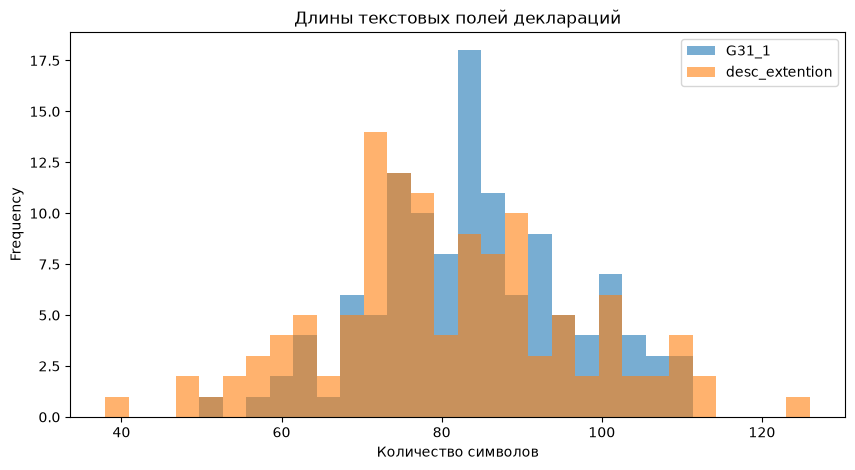

In [19]:
declarations[["G31_1", "desc_extention"]].apply(
    lambda column: column.fillna("").str.len()
).plot.hist(
    bins=30,
    alpha=0.6,
    figsize=(10, 5),
)

plt.title("Длины текстовых полей деклараций")
plt.xlabel("Количество символов")
plt.show()

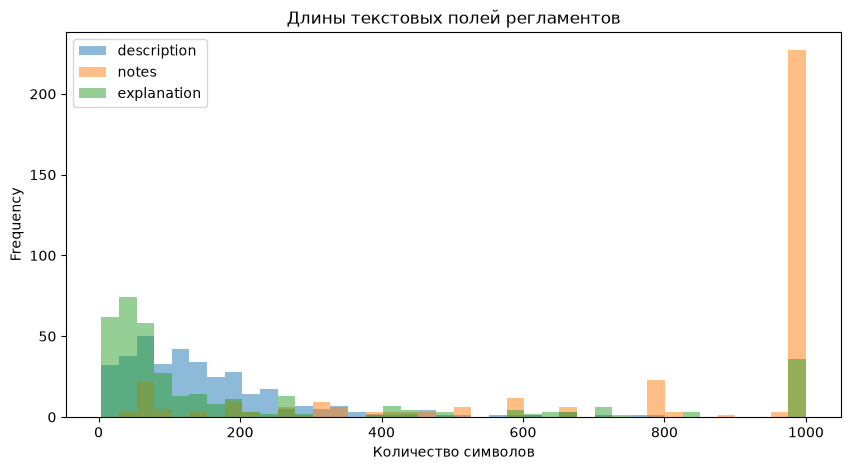

In [20]:
regulations[["description", "notes", "explanation"]].apply(
    lambda column: column.fillna("").str.len()
).plot.hist(
    bins=40,
    alpha=0.5,
    figsize=(10, 5),
)

plt.title("Длины текстовых полей регламентов")
plt.xlabel("Количество символов")
plt.show()

- `notes` значительно длиннее `description`
- Максимальная длина `notes` и `explanation` равна 1000 символам, поэтому тексты могли быть обрезаны при подготовке данных
- Длинное поле не обязательно содержит больше полезной информации
- Полное объединение `description`, `notes` и `explanation` может добавить повторяющийся контекст и ухудшить ранжирование
- Вклад каждого поля будет проверен отдельным экспериментом

## 7. Дубликаты текстов

In [21]:
def normalize_for_duplicate_check(series: pd.Series) -> pd.Series:
    return (
        series.fillna("")
        .astype(str)
        .str.lower()
        .str.replace("ё", "е")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [22]:
duplicate_checks = []

for column in ["G31_1", "desc_extention"]:
    normalized = normalize_for_duplicate_check(declarations[column])

    duplicate_checks.append({
        "dataset": "declarations",
        "column": column,
        "exact_duplicates": int(
            declarations[column].duplicated().sum()
        ),
        "normalized_duplicates": int(
            normalized.duplicated().sum()
        ),
    })

for column in ["description", "notes", "explanation"]:
    normalized = normalize_for_duplicate_check(regulations[column])

    duplicate_checks.append({
        "dataset": "regulations",
        "column": column,
        "exact_duplicates": int(
            regulations[column].duplicated().sum()
        ),
        "normalized_duplicates": int(
            normalized.duplicated().sum()
        ),
    })

pd.DataFrame(duplicate_checks)

,dataset,column,exact_duplicates,normalized_duplicates
0,declarations,G31_1,0,0
1,declarations,desc_extention,0,0
2,regulations,description,0,0
3,regulations,notes,267,267
4,regulations,explanation,178,178


In [23]:
for column in ["notes", "explanation"]:
    print(f"\n{column}")
    display(
        regulations[column]
        .value_counts()
        .head(5)
        .rename("repeat_count")
        .to_frame()
    )


notes


,repeat_count
notes,
"ГРУППА 29 ОРГАНИЧЕСКИЕ ХИМИЧЕСКИЕ СОЕДИНЕНИЯ Примечания: 1. Если в контексте не оговорено иное, в товарные позиции этой группы включаются только: (а) отдельные органические соединения определенного химического состава, содержащие или не содержащие примеси; (б) смеси двух или более изомеров одного и того же органического соединения (содержащего или не содержащего примеси), за исключением смесей изомеров ациклических углеводородов (но не стереоизомеров), насыщенных или ненасыщенных (группа 27); (в) продукты товарных позиций 2936 – 2939 или простые эфиры сахаров, ацетали сахаров, сложные эфиры сахаров, и их соли, товарной позиции 2940, или продукты товарной позиции 2941, определенного или неопределенного химического состава; (г) продукты, указанные выше в пунктах (а), (б) или (в), растворенные в воде; (д) продукты, указанные выше в пунктах (а), (б) или (в), растворенные в других растворителях, при условии, что растворение является обычным и необходимым способом, применяемым исключительно",18
"примечания 1 к группе 84 и примечания 1 к группе 85, части машин (кроме частей изделий товарной позиции 8484, 8544, 8545, 8546 или 8547) должны классифицироваться согласно следующим правилам: (а) части, которые являются товарами, включенными в какую-либо из товарных позиций группы 84 или 85 (кроме товарных позиций 8409, 8431, 8448, 8466, 8473, 8487, 8503, 8522, 8529, 8538 и 8548), во всех случаях должны классифицироваться в предусмотренных для них товарных позициях. (б) другие части, предназначенные для использования исключительно или главным образом с одним типом машин или с рядом машин той же товарной позиции (включая машины товарной позиции 8479 или 8543), должны классифицироваться вместе с этими машинами или в товарной позиции 8409, 8431, 8448, 8466, 8473, 8503, 8522, 8529 или",18
"7. В товарной позиции 8524 выражение ""модули с плоской дисплейной панелью"" относится к устройствам или аппаратам для отображения информации, оснащенным как минимум дисплейным экраном, которые сконструированы для встраивания в изделия других товарных позиций перед использованием. По форме дисплейные экраны таких модулей могут быть плоскими, изогнутыми, гибкими, складывающимися, растягивающимися или других форм. Модули с плоской дисплейной панелью могут включать в себя дополнительные компоненты, в том числе необходимые для приема видеосигналов и их распределения по пикселям экрана. В товарную позицию 8524, однако, не включаются дисплейные модули, оснащенные компонентами для преобразования видеосигналов (например, интегральной схемой преобразования видеоформата, интегральной схемой декодера или процессором приложений), или иным способом принявшие характер изделий других товарных позиций. При классификации модулей с плоской дисплейной панелью, указанных в данном примечании, товарная позици",12
"1. В субпозициях 8407 10 и 8409 10 термин ""авиационные двигатели"" должен применяться только к двигателям, предназначенным для сборки с воздушным или несущим винтом. 2. В подсубпозицию 8471 70 300 0 также включаются устройства считывания компакт-дисков, являющиеся запоминающими устройствами вычислительных машин, которые предназначены для считывания сигналов с CD-ROM, аудиокомпакт-дисков и фотокомпакт-дисков и снабжены разъемом для наушников, регулятором громкости или кнопкой пуск/стоп. Дополнительные примечания Евразийского экономического союза: 1. В подсубпозиции 8482 10 900 1 термин ""брутто-масса"" означает общую массу товара со всеми видами упаковочных материалов и тары, обеспечивающих его сохранность в процессе хранения и транспортировки. В общую массу товара не включается масса упаковочных материалов или тары, со всей очевидностью пригодных для повторного использования. 2. В подсубпозиции 8415 81 001 0 термин ""специальные производственные помещения"" означает помещения, в которых под",9
"ГРУППА 55 ХИМИЧЕСКИЕ ВОЛОКНА Примечание: 1.В товарные позиции 5501 и 5502 включается только жгут химических нитей, состоящий из параллельных нитей одинаковой


explanation


,repeat_count
explanation,
[8524],12
8407 34 – – с рабочим объемом цилиндров двигателя более 1000 см3,6
2710 19 – – прочие,6
"1701 14 В субпозицию включается только тростниковый сахар, полученный без центрифугирования, с массовой долей сахарозы в пересчете на сухое вещество, соответствующей показаниям поляриметра 69 или более, но менее 93. Продукт содержит только естественные ксеноморфные микрокристаллы неправильной формы, невидимые невооруженным глазом, окруженные остатками мелассы и другими составляющими сахарного тростника.",6
"8703 60 – транспортные средства, приводимые в движение как двигателем внутреннего сгорания с искровым зажиганием с возвратнопоступательным движением поршня, так и электрическим двигателем, которые могут заряжаться подключением к внешнему источнику электроэнергии, прочие",6


- В `notes` найдено 93 уникальных текста на 360 регламентов
- В `explanation` найдено 182 уникальных текста
- Нормализация регистра, пробелов и буквы `ё` не обнаружила дополнительных дубликатов
- Повторяющийся групповой контекст может мешать различению близких регламентов
- `notes` и `explanation` будут добавлены к основному тексту только при подтверждённом улучшении качества

## 8. Структура кодов ТН ВЭД

In [24]:
regulations["group"] = regulations["code"].str[:2]
regulations["position"] = regulations["code"].str[:4]
regulations["subposition"] = regulations["code"].str[:6]

group_counts = (
    regulations["group"]
    .value_counts()
    .sort_index()
    .to_frame()
)

display(group_counts)

,count
group,
02,12
03,12
04,9
08,6
09,3
11,3
12,3
15,6
16,3


In [25]:
regulations["group"].nunique()

49

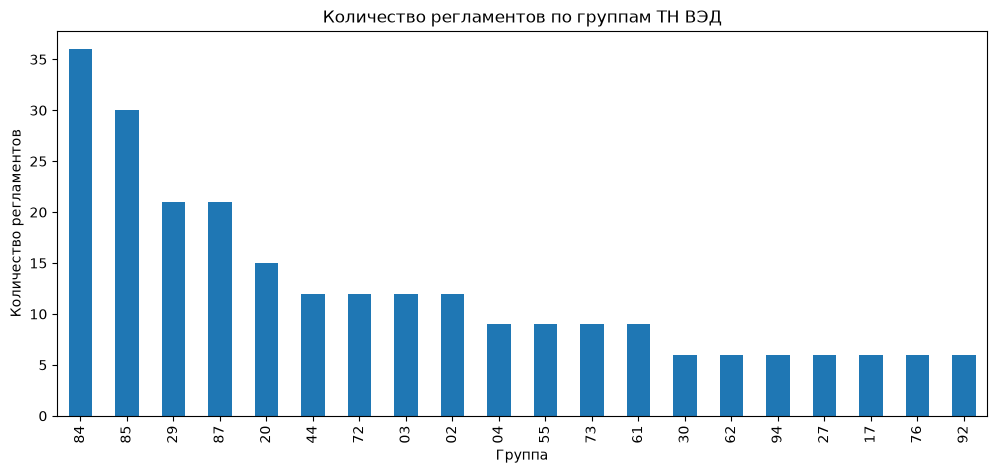

In [26]:
regulations["group"].value_counts().head(20).plot.bar(
    figsize=(12, 5),
)

plt.title("Количество регламентов по группам ТН ВЭД")
plt.xlabel("Группа")
plt.ylabel("Количество регламентов")
plt.show()

- Регламенты относятся к 49 группам ТН ВЭД
- Первый этап поиска должен определять общую товарную категорию и сохранять высокий Recall@K
- Второй этап должен различать близкие регламенты внутри одной категории
- Порядок строк и наблюдаемое расположение регламентов группами не используются как признаки

## 9. Покрытие кодов базой знаний

In [27]:
knowledge_codes = set()

for line in knowledge_text.splitlines():
    value_before_separator = line.split("|", maxsplit=1)[0].strip()

    if value_before_separator.isdigit() and 4 <= len(value_before_separator) <= 10:
        knowledge_codes.add(value_before_separator)

len(knowledge_codes)

18169

In [28]:
knowledge_coverage = regulations["code"].isin(knowledge_codes)

print(f"Кодов регламентов найдено в базе знаний: {int(knowledge_coverage.sum())} из {len(regulations)}")

display(
    regulations.loc[
        ~knowledge_coverage,
        ["regulation_id", "code", "description"],
    ]
)

Кодов регламентов найдено в базе знаний: 360 из 360


,regulation_id,code,description


In [29]:
print("\n".join(knowledge_text.splitlines()[:6]))

СПРАВОЧНЫЙ ДАМП ТН ВЭД ЕАЭС
Источник: https://tnved.info/TnvedTree/
Дата получения: 2026-07-20T13:32:37+00:00
Версия источника: 05.07.2022:2
Состав: 21 разделов, 96 групп, 21163 узлов, 13287 листовых кодов



## 10. Решение по каждому полю

In [30]:
field_decisions = pd.DataFrame([
    {
        "field": "G31_1",
        "decision": "использовать",
        "reason": "основное описание товара",
    },
    {
        "field": "desc_extention",
        "decision": "использовать",
        "reason": "состав, состояние, числа, исключения и назначение",
    },
    {
        "field": "G011",
        "decision": "проверить",
        "reason": "импорт и экспорт могут регулироваться по-разному",
    },
    {
        "field": "G34",
        "decision": "проверить позже",
        "reason": "страна может влиять на отдельные меры",
    },
    {
        "field": "G221 + G42",
        "decision": "не использовать в baseline",
        "reason": "стоимость имеет смысл только вместе с валютой",
    },
    {
        "field": "GD00",
        "decision": "исключить",
        "reason": "полностью пустое поле",
    },
    {
        "field": "GD0",
        "decision": "исключить при константности",
        "reason": "константный признак не помогает ранжированию",
    },
    {
        "field": "declaration_id",
        "decision": "не использовать как признак",
        "reason": "используется только для формирования результата",
    },
    {
        "field": "ND",
        "decision": "не использовать как признак",
        "reason": "регистрационный номер документа",
    },
    {
        "field": "G32",
        "decision": "не использовать как признак",
        "reason": "служебный номер товарной позиции",
    },
    {
        "field": "has_acceptance_docs",
        "decision": "не использовать в baseline",
        "reason": "риск утечки",
    },
    {
        "field": "permitting_docs",
        "decision": "не использовать в baseline",
        "reason": "может отражать уже выполненную проверку",
    },
    {
        "field": "description",
        "decision": "использовать",
        "reason": "основной текст регламента",
    },
    {
        "field": "notes",
        "decision": "проверить абляцией",
        "reason": "длинный и потенциально повторяющийся контекст",
    },
    {
        "field": "explanation",
        "decision": "проверить абляцией",
        "reason": "может уточнять категорию, но добавлять шум",
    }
])

field_decisions

,field,decision,reason
0,G31_1,использовать,основное описание товара
1,desc_extention,использовать,"состав, состояние, числа, исключения и назначение"
2,G011,проверить,импорт и экспорт могут регулироваться по-разному
3,G34,проверить позже,страна может влиять на отдельные меры
4,G221 + G42,не использовать в baseline,стоимость имеет смысл только вместе с валютой
5,GD00,исключить,полностью пустое поле
6,GD0,исключить при константности,константный признак не помогает ранжированию
7,declaration_id,не использовать как признак,используется только для формирования результата
8,ND,не использовать как признак,регистрационный номер документа
9,G32,не использовать как признак,служебный номер товарной позиции


In [31]:
future_features = pd.DataFrame([
    {
        "feature": "hierarchy_text",
        "source": "tnved_knowledge.txt",
        "decision": "проверить отдельным экспериментом",
        "reason": "может добавить смысл родительских категорий",
    },
])
future_features

,feature,source,decision,reason
0,hierarchy_text,tnved_knowledge.txt,проверить отдельным экспериментом,может добавить смысл родительских категорий


## 11. Выводы

- Загружено 120 деклараций и 360 регламентов
- Идентификаторы деклараций, регламентов и десятизначные коды уникальны
- Обязательные текстовые поля заполнены
- В данных представлены 90 импортных и 30 экспортных деклараций
- `GD0` является константным: во всех строках значение равно `10`
- `GD00` полностью пустое и исключается
- Допускающие документы присутствуют у 24 деклараций и согласуются с `has_acceptance_docs`
- Допускающие документы не используются в базовом решении из-за потенциальной процессной утечки
- Основной текст запроса формируется из `G31_1` и `desc_extention`
- Основным текстом регламента является `description`
- В `notes` найдено 93 уникальных текста на 360 регламентов
- В `explanation` найдено 182 уникальных текста
- Максимальная длина `notes` и `explanation` равна 1000 символам, поэтому тексты могли быть обрезаны
- Вклад `notes`, `explanation` и иерархии ТН ВЭД будет проверен отдельными абляциями
- Регламенты относятся к 49 группам ТН ВЭД
- Все 360 кодов регламентов присутствуют в предоставленном справочнике
- `declaration_id` используется только для формирования результата
- `ND`, `G32`, порядок строк и числовая часть `regulation_id` не используются как признаки
- Истинные метки отсутствуют, поэтому на этапе EDA нельзя честно вычислить Hit@K и MRR
- Используется версия справочника, предоставленная вместе с заданием